<a href="https://colab.research.google.com/github/Harika-11/AI-ML-Tasks/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [2]:
np.random.seed(42)

data_size = 200

study_hours = np.random.uniform(1, 10, data_size)
attendance = np.random.uniform(50, 100, data_size)
previous_scores = np.random.uniform(30, 100, data_size)

result = (study_hours * 5 + attendance * 0.3 + previous_scores * 0.5 > 100).astype(int)

df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'previous_scores': previous_scores,
    'result': result
})

df.head()

,study_hours,attendance,previous_scores,result
0,4.370861,82.101582,37.218671,0
1,9.556429,54.206998,93.178703,1
2,7.587945,58.081436,65.367666,0
3,6.387926,94.927709,87.852023,1
4,2.404168,80.321453,52.403472,0


In [3]:
X = df[['study_hours', 'attendance', 'previous_scores']]
y = df['result']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

In [7]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [8]:
def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

evaluate("Logistic Regression", y_test, log_pred)
evaluate("KNN", y_test, knn_pred)
evaluate("Random Forest", y_test, rf_pred)


Logistic Regression
Accuracy: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[32  0]
 [ 0  8]]

KNN
Accuracy: 0.875
F1 Score: 0.6153846153846154
Confusion Matrix:
 [[31  1]
 [ 4  4]]

Random Forest
Accuracy: 0.9
F1 Score: 0.7142857142857143
Confusion Matrix:
 [[31  1]
 [ 3  5]]


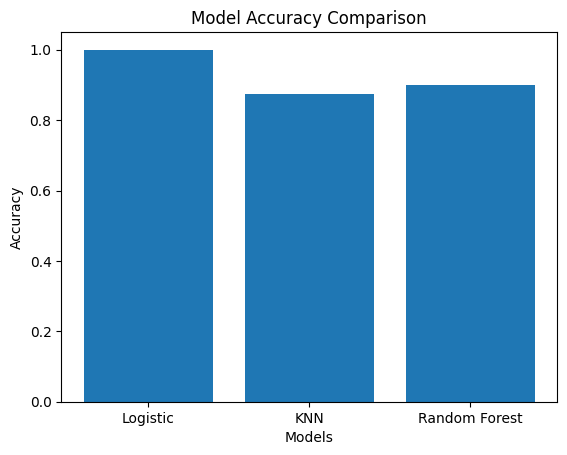

In [9]:
import matplotlib.pyplot as plt

models = ['Logistic', 'KNN', 'Random Forest']
accuracy = [
    accuracy_score(y_test, log_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, rf_pred)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()